In [121]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

In [122]:
df = pd.read_csv(
    "../data/events_features.csv"
)

print(df.shape)

df.head()

(8173, 59)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,year,duration_hours,cause_score,closure_score,priority_score,impact_score,risk_level,weekend,lat_grid,lon_grid
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,2024.0,NaN,2.0,0,5.0,7.0,Medium,0,13.04,77.52
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,2024.0,NaN,2.0,0,5.0,7.0,Medium,0,12.92,77.65
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,2023.0,NaN,3.0,0,1.0,4.0,Low,1,12.96,77.59
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,2024.0,NaN,5.0,5,1.0,11.0,High,0,13.01,77.58
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,2024.0,NaN,2.0,0,1.0,3.0,Low,0,12.95,77.59


In [123]:
density_map = (
    df.groupby(
        ["lat_grid", "lon_grid"]
    )
    .size()
    .to_dict()
)

df["event_density"] = df.apply(
    lambda row:
    density_map.get(
        (
            row["lat_grid"],
            row["lon_grid"]
        ),
        0
    ),
    axis=1
)

In [124]:
df["event_density"].describe()

count    8173.000000
mean       51.263306
std        38.410252
min         1.000000
25%        19.000000
50%        42.000000
75%        83.000000
max       137.000000
Name: event_density, dtype: float64

In [125]:
features = [
    "event_type",
    "event_cause",
    "requires_road_closure",
    "hour",
    "day_of_week",
    "month",
    "weekend",
    "zone",
    "corridor",
    "junction",
    "latitude",
    "longitude",
    "event_density"
]

target = "risk_level"

In [126]:
X = df[features].copy()

y = df[target]

In [127]:
X["zone"] = X["zone"].fillna(
    "Unknown"
)

X["corridor"] = X["corridor"].fillna(
    "Unknown"
)

X["junction"] = X["junction"].fillna(
    "Unknown"
)

In [128]:
label_encoders = {}

categorical_cols = [
    "event_type",
    "event_cause",
    "zone",
    "corridor",
    "junction"
]

for col in categorical_cols:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = le

In [129]:
target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(
    y
)

In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.7,
    random_state=42,
    stratify=y_encoded
)

In [131]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [132]:
preds = model.predict(
    X_test
)

In [133]:
acc = accuracy_score(
    y_test,
    preds
)

print(
    f"Accuracy: {acc:.4f}"
)

Accuracy: 0.9886


In [134]:
print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.88      0.82      0.85        93
           1       0.96      0.98      0.97       676
           2       1.00      0.99      0.99      1528
           3       0.99      1.00      0.99      3425

    accuracy                           0.99      5722
   macro avg       0.96      0.94      0.95      5722
weighted avg       0.99      0.99      0.99      5722



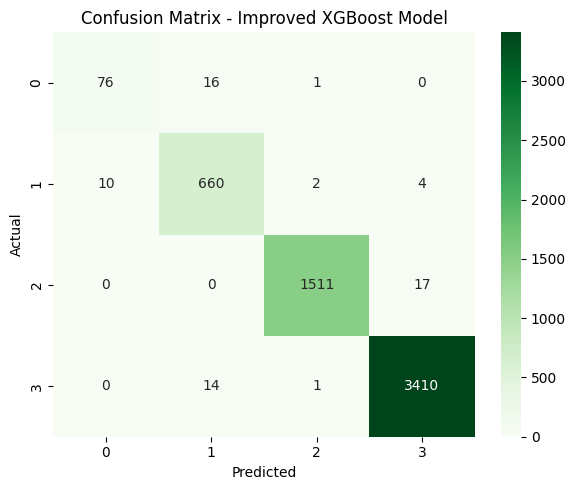

In [135]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Improved XGBoost Model")

plt.tight_layout()
plt.show()

In [136]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds, average="macro")
recall = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print(metrics)

      Metric     Score
0   Accuracy  0.988640
1  Precision  0.957870
2     Recall  0.988640
3   F1 Score  0.988584


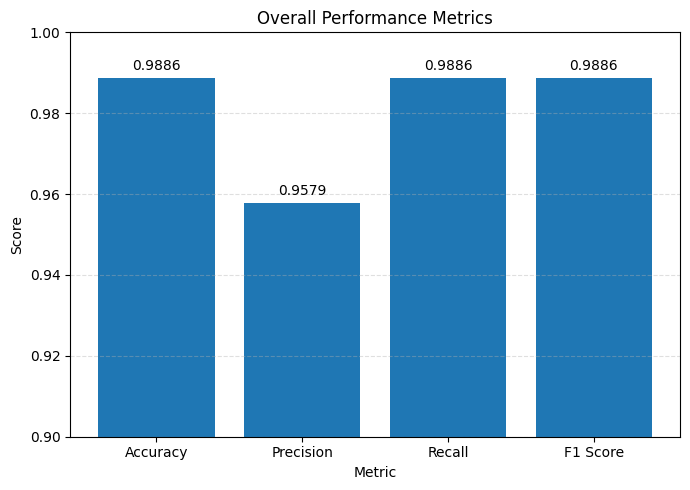

In [149]:
import matplotlib.pyplot as plt

# Use the DataFrame that you printed above
metric_names = metrics["Metric"]
metric_values = metrics["Score"]

plt.figure(figsize=(7,5))

bars = plt.bar(metric_names, metric_values)

plt.ylim(0.90, 1.00)
plt.title("Overall Performance Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")

# Value labels
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.002,
        f"{h:.4f}",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [137]:
print("Accuracy :", round(accuracy_score(y_test, preds),4))

print("Weighted Precision:", round(precision_score(y_test,preds,average='weighted'),4))
print("Weighted Recall   :", round(recall_score(y_test,preds,average='weighted'),4))
print("Weighted F1       :", round(f1_score(y_test,preds,average='weighted'),4))

print()

print("Macro Precision:", round(precision_score(y_test,preds,average='macro'),4))
print("Macro Recall   :", round(recall_score(y_test,preds,average='macro'),4))
print("Macro F1       :", round(f1_score(y_test,preds,average='macro'),4))

Accuracy : 0.9886
Weighted Precision: 0.9886
Weighted Recall   : 0.9886
Weighted F1       : 0.9886

Macro Precision: 0.9579
Macro Recall   : 0.9445
Macro F1       : 0.9508


In [138]:
importance_df = pd.DataFrame(
    {
        "feature": X.columns,
        "importance": model.feature_importances_
    }
)

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df

,feature,importance
8,corridor,0.300951
2,requires_road_closure,0.245772
1,event_cause,0.180857
0,event_type,0.140940
11,longitude,0.023807
12,event_density,0.019015
7,zone,0.016415
10,latitude,0.015927
3,hour,0.014342
9,junction,0.013409


In [139]:
importance_df.head(15)

,feature,importance
8,corridor,0.300951
2,requires_road_closure,0.245772
1,event_cause,0.180857
0,event_type,0.140940
11,longitude,0.023807
12,event_density,0.019015
7,zone,0.016415
10,latitude,0.015927
3,hour,0.014342
9,junction,0.013409


In [140]:
pd.crosstab(
    df["corridor"],
    df["risk_level"]
)

risk_level,Critical,High,Low,Medium
corridor,,,,
Airport New South Road,5,21,0,41
Bannerghata Road,2,15,0,192
Bellary Road 1,6,62,0,542
Bellary Road 2,5,68,0,306
CBD 1,1,2,0,23
CBD 2,1,15,0,88
Hennur Main Road,3,39,0,54
Hosur Road,4,32,0,262
IRR(Thanisandra road),2,10,0,83


In [141]:
pd.crosstab(
    df["event_type"],
    df["risk_level"]
)

risk_level,Critical,High,Low,Medium
event_type,,,,
planned,94,296,1,76
unplanned,39,670,2181,4816


In [142]:
pd.crosstab(
    df["event_cause"],
    df["risk_level"]
)

risk_level,Critical,High,Low,Medium
event_cause,,,,
Debris,0,0,3,9
Fog / Low Visibility,0,0,1,1
accident,5,169,0,191
congestion,2,96,0,38
construction,68,293,0,119
debris,0,1,0,0
others,0,30,233,375
pot_holes,0,5,230,302
procession,19,53,0,0


In [143]:
for col in [
    "corridor",
    "junction",
    "zone"
]:
    print("\n")
    print(col)

    print(
        df.groupby(col)[
            "risk_level"
        ].value_counts(
            normalize=True
        )
        .head(20)
    )



corridor
corridor                risk_level
Airport New South Road  Medium        0.611940
                        High          0.313433
                        Critical      0.074627
Bannerghata Road        Medium        0.918660
                        High          0.071770
                        Critical      0.009569
Bellary Road 1          Medium        0.888525
                        High          0.101639
                        Critical      0.009836
Bellary Road 2          Medium        0.807388
                        High          0.179420
                        Critical      0.013193
CBD 1                   Medium        0.884615
                        High          0.076923
                        Critical      0.038462
CBD 2                   Medium        0.846154
                        High          0.144231
                        Critical      0.009615
Hennur Main Road        Medium        0.562500
                        High          0.406250
Name: proporti

In [144]:
import joblib

joblib.dump(
    model,
    "../backend/ml/saved_models/risk_model_v2.pkl"
)

['../backend/ml/saved_models/risk_model_v2.pkl']

In [145]:
joblib.dump(
    target_encoder,
    "../backend/ml/encoders/target_encoder_v2.pkl"
)

['../backend/ml/encoders/target_encoder_v2.pkl']

In [146]:
joblib.dump(
    label_encoders,
    "../backend/ml/encoders/feature_encoders_v2.pkl"
)

['../backend/ml/encoders/feature_encoders_v2.pkl']